# Kalman Filtering and Bayesian Changepoint Detection

Classical trend filters (SMA, EWMA, Donchian) all implement the same idea with a **fixed** lookback, which is the trade-off on slide 11 of the lecture: short windows false-trigger, long windows lag reversals. Two adaptive alternatives replace that fixed window with a state.

**Local linear trend (Kalman).** Prices are a latent level plus a latent velocity, both of which are allowed to wander:

$$y_t = L_t + \varepsilon_t, \qquad L_t = L_{t-1} + T_{t-1} + \eta_{1,t}, \qquad T_t = T_{t-1} + \eta_{2,t}$$

The Kalman *gain* shrinks when observations are noisy and expands when the trend is moving, so the effective lookback is time-varying. The trading signal is $\operatorname{sign}(\hat T_{t-1})$, the filtered velocity from yesterday.

**Bayesian online changepoint detection (Adams & MacKay 2007).** Instead of estimating a velocity, BOCPD maintains a posterior over the **run length** $r_t$ since the last structural break. After a V-bottom the mass on short run lengths spikes, which is the cue to cut leverage — the same job CUSUM was doing in `momentum_strategies.ipynb`, with a full posterior instead of a pair of one-sided sums.

This notebook asks two empirical questions on the same 10-ETF, 2007–2024 sample:

1. Does a Kalman velocity signal beat the EWMA crossover it is supposed to replace?
2. Does BOCPD de-leverage unscaled XSMOM more usefully than CUSUM, or is the Sharpe lift still noise?


In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display
from scipy import stats
from scipy.special import gammaln
from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="A date index has been provided")

TRADING_DAYS = 252
WARMUP = 504          # 2 years of daily bars for Kalman MLE and expanding moments
TARGET_VOL = 0.15
HAZARD = 1.0 / 250    # BOCPD: expected regime length ~ 1 year
YOUNG = 21            # run length (days) treated as "still in a new regime"
EVAL_START = "2008-01-02"  # regime filters are scored from here, as in momentum_strategies.ipynb

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

csv_path = "real_market_data.csv"
tickers = ["SPY", "QQQ", "IWM", "EEM", "EFA", "TLT", "LQD", "GLD", "DBC", "VNQ"]
if os.path.exists(csv_path):
    df_prices = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    df_prices = yf.download(tickers, start="2007-01-01", end="2024-06-01")["Close"].dropna()
    df_prices.to_csv(csv_path)

df_returns = df_prices.pct_change()
print(f"Loaded {df_prices.index[0]:%Y-%m-%d} → {df_prices.index[-1]:%Y-%m-%d}")
print(f"Universe ({df_prices.shape[1]}): {list(df_prices.columns)}")
print(f"Sharpe required for t = 2 on this sample: {2 / np.sqrt(len(df_prices) / TRADING_DAYS):.2f}")


Loaded 2007-01-03 → 2024-05-31
Universe (10): ['DBC', 'EEM', 'EFA', 'GLD', 'IWM', 'LQD', 'QQQ', 'SPY', 'TLT', 'VNQ']
Sharpe required for t = 2 on this sample: 0.48


## 1. Filter equivalence (Hamdan et al. 2012, Bruder & Gaussel 2011)

Any *linear* moving-average filter is a convolution $s_{t-1} = \sum_k \phi_k r_{t-k}$. Different $\phi$ change the lag weights, not the strategy, which is why SMA and EWMA should print return correlations above 0.90 (Hamdan et al. 2012). Donchian is a **nonlinear** breakout rule — it only flips at a rolling max/min — so the theorem does not apply to it; a low correlation there is expected, not a failure. Kalman is the interesting case in between: its gain is state-dependent, so it is not a fixed linear filter. If Kalman-TSMOM is just EWMA with extra steps, the return correlation will sit with SMA/EWMA above 0.90; if the time-varying gain is doing work, it will sit below.


In [2]:
def vol_scaled_returns(signal: pd.DataFrame, prices: pd.DataFrame) -> pd.Series:
    ret = prices.pct_change()
    # min_periods: a vol estimated on 2-3 returns would size the first positions at ~10x
    ann_vol = (ret.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.01)
    pos = signal * (TARGET_VOL / ann_vol)
    return (pos.shift(1) * ret).mean(axis=1)


def sma_signal(prices, fast=32, slow=96):
    return np.sign(prices.rolling(fast).mean() - prices.rolling(slow).mean())


def ewma_signal(prices, fast=32, slow=96):
    return np.sign(prices.ewm(span=fast, adjust=False).mean() - prices.ewm(span=slow, adjust=False).mean())


def donchian_signal(prices, window=20):
    hi = prices.rolling(window).max()
    lo = prices.rolling(window).min()
    raw = pd.DataFrame(
        np.where(prices >= hi, 1.0, np.where(prices <= lo, -1.0, np.nan)),
        index=prices.index, columns=prices.columns,
    )
    return raw.ffill().fillna(0.0)


sig_sma = sma_signal(df_prices)
sig_ewma = ewma_signal(df_prices)
sig_don = donchian_signal(df_prices)

ret_sma = vol_scaled_returns(sig_sma, df_prices)
ret_ewma = vol_scaled_returns(sig_ewma, df_prices)
ret_don = vol_scaled_returns(sig_don, df_prices)


def mean_position_corr(a: pd.DataFrame, b: pd.DataFrame) -> float:
    paired = pd.concat([a.stack(), b.stack()], axis=1).dropna()
    paired.columns = ["a", "b"]
    return paired["a"].corr(paired["b"])


equiv = pd.DataFrame({
    "SMA 32/96": ret_sma, "EWMA 32/96": ret_ewma, "Donchian 20": ret_don,
}).dropna()
print("Strategy-return correlations")
display(equiv.corr().round(3))
print(
    f"Mean pairwise position correlation  SMA vs EWMA : {mean_position_corr(sig_sma, sig_ewma):.3f}\n"
    f"Mean pairwise position correlation  SMA vs Donchian: {mean_position_corr(sig_sma, sig_don):.3f}\n"
    f"Mean pairwise position correlation  EWMA vs Donchian: {mean_position_corr(sig_ewma, sig_don):.3f}"
)


Strategy-return correlations


,SMA 32/96,EWMA 32/96,Donchian 20
SMA 32/96,1.000,0.906,0.272
EWMA 32/96,0.906,1.000,0.374
Donchian 20,0.272,0.374,1.000


Mean pairwise position correlation  SMA vs EWMA : 0.799
Mean pairwise position correlation  SMA vs Donchian: 0.211
Mean pairwise position correlation  EWMA vs Donchian: 0.297


## 2. Kalman local linear trend

Process and measurement variances $(\sigma_\varepsilon^2, \sigma_{\eta_1}^2, \sigma_{\eta_2}^2)$ are estimated by MLE on the **first two years of each asset**, then frozen. The Kalman filter is then run on the full sample with those fixed hyperparameters, and we take the *filtered* (not smoothed) trend. Smoothing would use $y_{t+1}, y_{t+2}, \ldots$ and is look-ahead; filtering at $t$ uses $y_t$, so the position is lagged one more day.

During the warmup there is no frozen $Q, R$ yet, so the strategy holds nothing (NaNs, not zeros — filling with zero would shrink the downstream EWMA volatility and inflate later leverage, the same trap as in `momentum_strategies.ipynb`).


In [3]:
def kalman_trend(prices: pd.Series, warmup: int = WARMUP) -> pd.Series:
    logp = np.log(prices.replace(0, np.nan)).dropna()
    warm = logp.iloc[:warmup]
    res = UnobservedComponents(warm, level="local linear trend").fit(disp=False, maxiter=200)
    filt = UnobservedComponents(logp, level="local linear trend").filter(res.params)
    trend = pd.Series(filt.filtered_state[1], index=logp.index)
    # no signal until hyperparameters exist
    trend.iloc[:warmup] = np.nan
    return trend.reindex(prices.index)


kalman_trends = pd.concat({c: kalman_trend(df_prices[c]) for c in df_prices.columns}, axis=1)
sig_kalman = np.sign(kalman_trends)
ret_kalman = vol_scaled_returns(sig_kalman, df_prices)

print("Kalman hyperparameters frozen after warmup; filtered velocity is the signal.")
_post = slice(WARMUP + 1, None)  # both engines on the same post-warmup days
print(f"EWMA   TSMOM Sharpe (post-warmup):                  {np.sqrt(TRADING_DAYS) * ret_ewma.iloc[_post].mean() / ret_ewma.iloc[_post].std():.2f}")
print(f"Kalman TSMOM Sharpe (post-warmup):                  {np.sqrt(TRADING_DAYS) * ret_kalman.iloc[_post].mean() / ret_kalman.iloc[_post].std():.2f}")
print(f"Return correlation EWMA vs Kalman (post-warmup):    {ret_ewma.iloc[WARMUP:].corr(ret_kalman.iloc[WARMUP:]):.3f}")
print(f"Mean position correlation EWMA vs Kalman:           {mean_position_corr(sig_ewma.iloc[WARMUP:], sig_kalman.iloc[WARMUP:]):.3f}")


Kalman hyperparameters frozen after warmup; filtered velocity is the signal.
EWMA   TSMOM Sharpe (post-warmup):                  0.56
Kalman TSMOM Sharpe (post-warmup):                  0.62
Return correlation EWMA vs Kalman (post-warmup):    0.748
Mean position correlation EWMA vs Kalman:           0.502


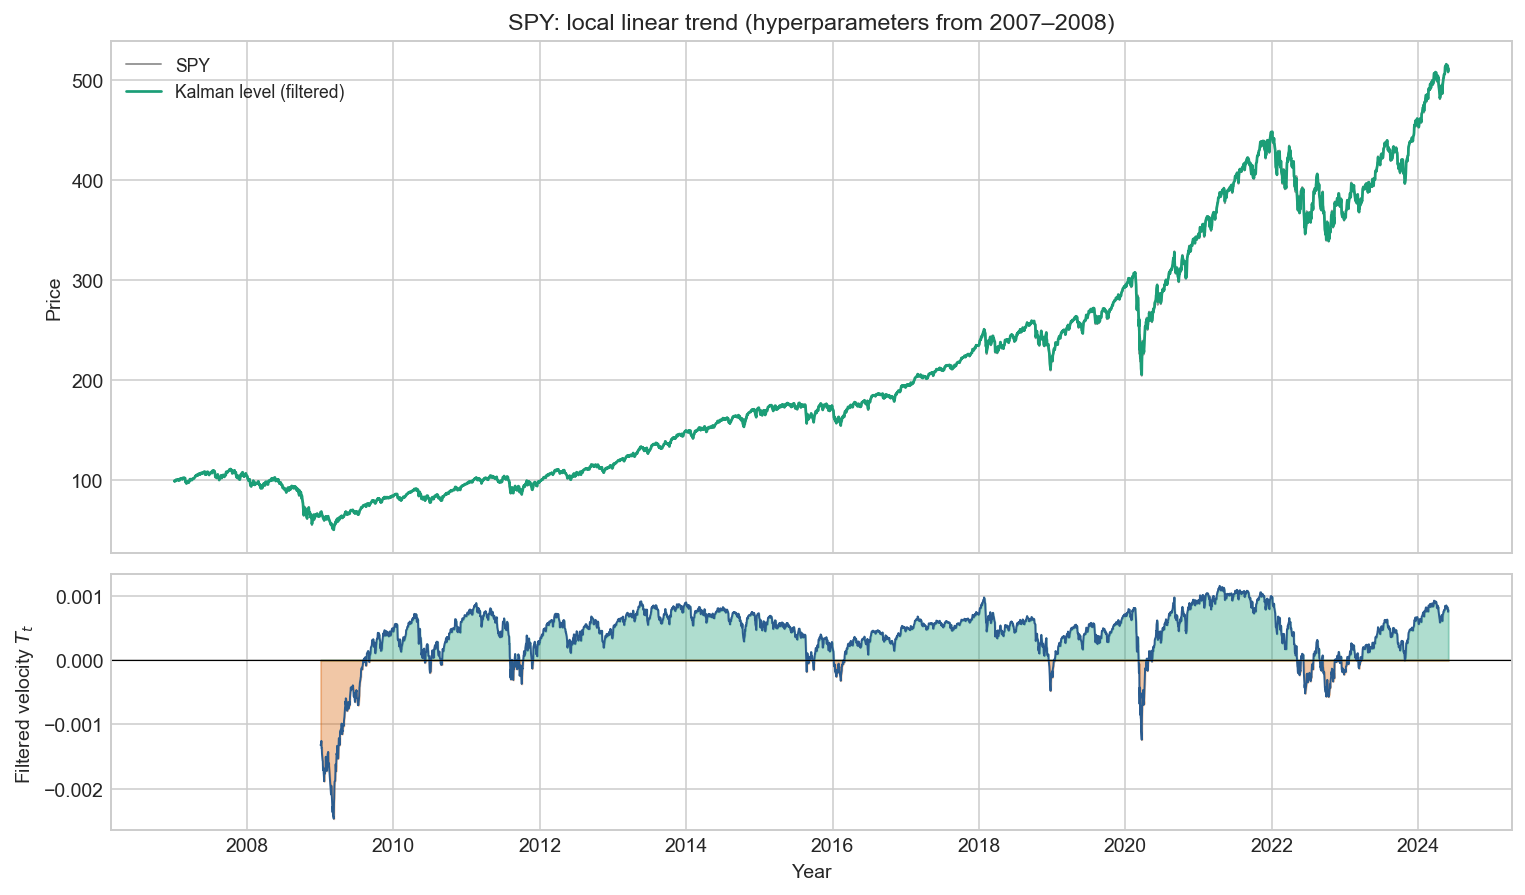

In [4]:
spy_px = df_prices["SPY"]
spy_lvl = np.exp(pd.Series(
    UnobservedComponents(np.log(spy_px), level="local linear trend")
    .filter(
        UnobservedComponents(np.log(spy_px).iloc[:WARMUP], level="local linear trend")
        .fit(disp=False, maxiter=200).params
    ).filtered_state[0],
    index=spy_px.index,
))
spy_tr = kalman_trends["SPY"]

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), dpi=140, sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(spy_px, color="#999999", lw=1.0, label="SPY")
axes[0].plot(spy_lvl, color="#1b9e77", lw=1.4, label="Kalman level (filtered)")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_title("SPY: local linear trend (hyperparameters from 2007–2008)")
axes[1].plot(spy_tr, color="#2b5c8f", lw=1.0)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].fill_between(spy_tr.index, 0, spy_tr.clip(lower=0), color="#1b9e77", alpha=0.35)
axes[1].fill_between(spy_tr.index, 0, spy_tr.clip(upper=0), color="#d95f02", alpha=0.35)
axes[1].set_ylabel("Filtered velocity $T_t$")
axes[1].set_xlabel("Year")
fig.tight_layout()
plt.show()


## 3. Unscaled XSMOM, the crash-prone book

CUSUM and BOCPD are regime filters, not trend engines. They are applied to the **unscaled** 6-month cross-sectional book from the companion notebook — long top 3 / short bottom 3, no volatility targeting — because that is the series that actually crashes. As in the companion notebook, the book holds nothing until every name has a 126-day lookback and is scored from 2008-01-02. A filter that looks useful on already-vol-scaled TSMOM is solving the wrong problem.


In [5]:
class CrossSectionalMomentum:
    def __init__(self, lookback=126, top_k=3, target_vol=0.15, vol_scaled=True):
        self.lookback, self.top_k = lookback, top_k
        self.target_vol, self.vol_scaled = target_vol, vol_scaled

    def run(self, prices: pd.DataFrame) -> pd.Series:
        ret = prices.pct_change()
        past = prices.pct_change(self.lookback)
        ann_vol = (ret.rolling(60).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.01)
        score = past / ann_vol if self.vol_scaled else past
        ranks = score.rank(axis=1, ascending=False)
        long_m = (ranks <= self.top_k).astype(float)
        short_m = (ranks > (prices.shape[1] - self.top_k)).astype(float)
        # no book until every name has a full lookback
        weights = ((long_m - short_m) / (2 * self.top_k)).where(score.notna().all(axis=1))
        raw = (weights.shift(1) * ret).sum(axis=1, min_count=1)
        if not self.vol_scaled:
            return raw
        strat_vol = (raw.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(TRADING_DAYS)).clip(lower=0.02)
        return raw * (self.target_vol / strat_vol).shift(1)


xsmom_unscaled = CrossSectionalMomentum(vol_scaled=False).run(df_prices)
_x = xsmom_unscaled.loc[EVAL_START:]
print(f"First trading day: {xsmom_unscaled.first_valid_index():%Y-%m-%d}")
print(f"Unscaled XSMOM Sharpe ({EVAL_START[:4]}–2024): {np.sqrt(TRADING_DAYS) * _x.mean() / _x.std():.2f}")

First trading day: 2007-07-06
Unscaled XSMOM Sharpe (2008–2024): 0.05


## 4. CUSUM (baseline) versus BOCPD

CUSUM, copied from the companion notebook, standardizes with expanding moments lagged one day (126-day warmup, so both filters go live in the first week of 2008) and de-levers to 25% on the single day a two-sided sum crosses $h = 2.5$.

BOCPD (Adams & MacKay 2007) puts a constant hazard $H = 1/250$ on run-length growth and a normal-inverse-gamma prior on each regime's mean and variance. The predictive is Student-$t$. One identity is easy to miss and would make a wrong notebook:

$$\Pr(r_t = 0 \mid x_{1:t}) = H \quad \text{identically, under constant hazard.}$$

The hazard is data-independent, so the posterior mass on run length *zero* never spikes. What *does* spike after a break is the mass on **short** run lengths: $\Pr(r_t < L)$. We take $L = 21$ trading days and set

$$\lambda_t = 1 - 0.75\,\Pr(r_t < 21), \qquad r^{\text{BOCPD}}_t = \lambda_{t-1}\, r^{\text{XS}}_t$$

so a certain young-regime posterior cuts exposure to 25%, matching CUSUM's floor, while uncertain mass scales smoothly. Both filters see only $x_{1:t}$ (CUSUM's $z_t$ uses moments through $t-1$; BOCPD's posterior at $t$ uses $x_t$, hence the extra lag on $\lambda$).

Two start-up details matter for the day counts. BOCPD is run only on days where the $z$-score exists; padding the warmup with zeros would present it with a fake variance break on the first real observation. And for the first 21 observations $\Pr(r_t < 21) = 1$ by construction, because the run cannot be longer than the data seen so far, so those days are set to zero rather than counted as detections.


In [6]:
def cusum_regime_filter(series: pd.Series, threshold=2.5, warmup=126) -> pd.Series:
    mu = series.expanding(min_periods=warmup).mean().shift(1)
    sigma = series.expanding(min_periods=warmup).std().shift(1)
    z = ((series - mu) / (sigma + 1e-6)).fillna(0.0)
    pos_sum = neg_sum = 0.0
    weights = np.ones(len(series))
    for i in range(1, len(series)):
        pos_sum = max(0.0, pos_sum + z.iloc[i] - 0.5)
        neg_sum = max(0.0, neg_sum - z.iloc[i] - 0.5)
        if pos_sum > threshold or neg_sum > threshold:
            weights[i] = 0.25
            pos_sum = neg_sum = 0.0
    return pd.Series(weights, index=series.index)


def bocpd_young_prob(x, hazard=HAZARD, young=YOUNG, mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0):
    # Adams & MacKay 2007, NIG / Student-t predictive, constant hazard.
    # Returns Pr(run length < young) at each t. P(r=0) is identically `hazard`.
    x = np.asarray(x, dtype=float)
    T = len(x)
    logR = np.full((T + 1, T + 1), -np.inf)
    logR[0, 0] = 0.0
    mu = np.array([mu0]); kappa = np.array([kappa0])
    alpha = np.array([alpha0]); beta = np.array([beta0])
    log_h, log_1mh = np.log(hazard), np.log(1.0 - hazard)
    p_young = np.zeros(T)
    map_run = np.zeros(T, dtype=int)

    def log_pred(xt, mu, kappa, alpha, beta):
        df = 2.0 * alpha
        var = np.clip(beta * (kappa + 1.0) / (alpha * kappa), 1e-12, None)
        z2 = (xt - mu) ** 2 / var
        return (
            gammaln((df + 1.0) / 2.0) - gammaln(df / 2.0)
            - 0.5 * np.log(df * np.pi * var)
            - ((df + 1.0) / 2.0) * np.log1p(z2 / df)
        )

    for t in range(T):
        n = t + 1
        lp = log_pred(x[t], mu, kappa, alpha, beta)
        logR[t + 1, 1:n + 1] = logR[t, :n] + lp + log_1mh
        m = np.max(logR[t, :n] + lp)
        logR[t + 1, 0] = log_h + m + np.log(np.sum(np.exp(logR[t, :n] + lp - m)))
        row = logR[t + 1, :n + 1]
        m = np.max(row)
        logR[t + 1, :n + 1] = row - (m + np.log(np.sum(np.exp(row - m))))
        post = np.exp(logR[t + 1, :n + 1])
        p_young[t] = post[: min(young, n + 1)].sum()
        map_run[t] = int(post.argmax())
        k, m_, a, b = kappa, mu, alpha, beta
        mu = np.empty(n + 1); kappa = np.empty(n + 1)
        alpha = np.empty(n + 1); beta = np.empty(n + 1)
        mu[0], kappa[0], alpha[0], beta[0] = mu0, kappa0, alpha0, beta0
        mu[1:] = (k * m_ + x[t]) / (k + 1.0)
        kappa[1:] = k + 1.0
        alpha[1:] = a + 0.5
        beta[1:] = b + 0.5 * k * (x[t] - m_) ** 2 / (k + 1.0)
    return p_young, map_run


# Causal z-score of the XSMOM book, then BOCPD on unit-scale data so beta0=1 is a reasonable prior.
# BOCPD only sees days on which the z-score exists. Padding the warmup with zeros
# would hand it a fake variance break on the first real observation.
mu_x = xsmom_unscaled.expanding(min_periods=126).mean().shift(1)
sd_x = xsmom_unscaled.expanding(min_periods=126).std().shift(1)
z_x = ((xsmom_unscaled - mu_x) / (sd_x + 1e-6)).dropna()

cusum_w = cusum_regime_filter(xsmom_unscaled, warmup=126)
p_young, map_run = bocpd_young_prob(z_x.to_numpy())
p_young = pd.Series(p_young, index=z_x.index)
# The first YOUNG days are "young" by construction (the run cannot be longer than
# the data seen so far), not because anything was detected.
p_young.iloc[:YOUNG] = 0.0
p_young = p_young.reindex(xsmom_unscaled.index).fillna(0.0)
bocpd_w = 1.0 - 0.75 * p_young

xsmom_cusum = xsmom_unscaled * cusum_w.shift(1)
xsmom_bocpd = xsmom_unscaled * bocpd_w.shift(1)

cusum_hits = (cusum_w < 1).loc[EVAL_START:]
bocpd_hits = (p_young > 0.5).loc[EVAL_START:]
print(f"Filters live from {z_x.index[0]:%Y-%m-%d}")
print(f"CUSUM detections (weight < 1): {cusum_hits.sum()} days")
print(f"BOCPD days with Pr(r < {YOUNG}) > 0.5: {bocpd_hits.sum()}")
print("Flagged days by year:")
print(pd.DataFrame({
    "CUSUM": cusum_hits.groupby(cusum_hits.index.year).sum(),
    "BOCPD": bocpd_hits.groupby(bocpd_hits.index.year).sum(),
}).T.to_string())

Filters live from 2008-01-04
CUSUM detections (weight < 1): 70 days
BOCPD days with Pr(r < 21) > 0.5: 207
Flagged days by year:
Date   2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024
CUSUM    31     4     0    13     0     0     0     1     1     0     1     0    15     0     4     0     0
BOCPD    19     7     0    18     0     1    13    21    26     1    21    23    30     0    27     0     0


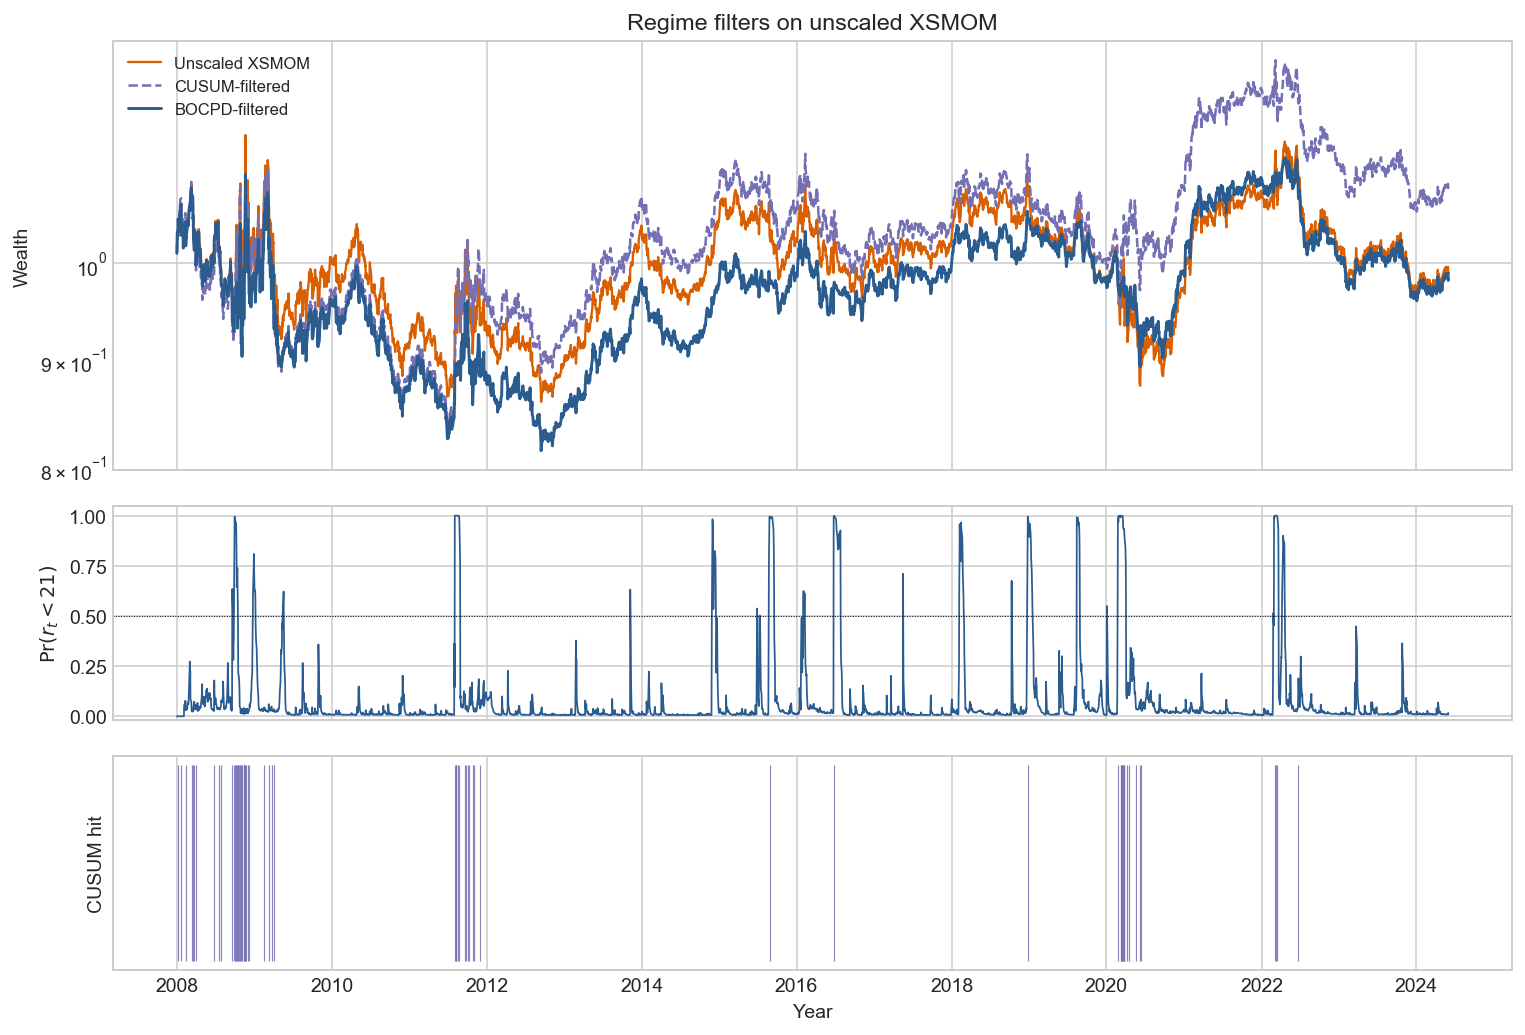

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), dpi=140, sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
wealth_u = (1 + xsmom_unscaled.loc[EVAL_START:]).cumprod()
axes[0].plot(wealth_u, color="#d95f02", lw=1.2, label="Unscaled XSMOM")
axes[0].plot((1 + xsmom_cusum.loc[EVAL_START:]).cumprod(), color="#7570b3", lw=1.3, ls="--", label="CUSUM-filtered")
axes[0].plot((1 + xsmom_bocpd.loc[EVAL_START:]).cumprod(), color="#2b5c8f", lw=1.5, label="BOCPD-filtered")
axes[0].set_yscale("log")
axes[0].set_ylabel("Wealth")
axes[0].legend(loc="upper left", fontsize=8.5)
axes[0].set_title("Regime filters on unscaled XSMOM")

axes[1].plot(p_young.loc[EVAL_START:], color="#2b5c8f", lw=0.9)
axes[1].axhline(0.5, color="k", lw=0.5, ls=":")
axes[1].set_ylabel(r"$\Pr(r_t < 21)$")
axes[1].set_ylim(-0.02, 1.05)

det = (cusum_w < 1) & (cusum_w.index >= EVAL_START)
axes[2].vlines(cusum_w.index[det], 0, 1, color="#7570b3", lw=0.6, alpha=0.85)
axes[2].set_ylabel("CUSUM hit")
axes[2].set_yticks([])
axes[2].set_xlabel("Year")
fig.tight_layout()
plt.show()


## 5. Performance comparison

Same conventions as the companion notebook: geometric CAGR, Sortino with MAR $= 0$ averaged over all days, Calmar $= \text{CAGR}/|\text{MDD}|$, drawdown length counted only for episodes that trough below $-5\%$. Trend engines are scored on the post-warmup window so Kalman's frozen $Q, R$ are in force. Regime filters are scored from **2008-01-02**, the companion notebook's window — a 2009 start would drop 2008, the crash they exist to handle.


In [8]:
def performance_stats(returns: pd.Series, depth=0.05) -> dict:
    r = returns.dropna()
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    cagr = wealth.iloc[-1] ** (TRADING_DAYS / len(r)) - 1
    max_dd = drawdown.min()
    downside = np.sqrt((r.clip(upper=0) ** 2).mean())
    underwater = wealth < peak
    runs = underwater.ne(underwater.shift()).cumsum()
    lengths = underwater.groupby(runs).sum()
    material = lengths[drawdown.groupby(runs).min() <= -depth]
    return {
        "Ann. Return": cagr,
        "Ann. Vol": r.std() * np.sqrt(TRADING_DAYS),
        "Sharpe": np.sqrt(TRADING_DAYS) * r.mean() / r.std(),
        "Sortino": np.sqrt(TRADING_DAYS) * r.mean() / downside,
        "Max DD": max_dd,
        "Calmar": cagr / abs(max_dd),
        f"DD > {depth:.0%}": len(material),
        "Avg DD (days)": float(material.mean()) if len(material) else 0.0,
        "Longest DD (days)": float(material.max()) if len(material) else 0.0,
    }


def stats_table(strategies: dict) -> pd.DataFrame:
    table = pd.DataFrame([performance_stats(v) for v in strategies.values()], index=list(strategies))
    shown = table.copy()
    for col in ("Ann. Return", "Ann. Vol", "Max DD"):
        shown[col] = table[col].map(lambda v: f"{100 * v:.1f}%")
    for col in ("Sharpe", "Sortino", "Calmar"):
        shown[col] = table[col].map(lambda v: f"{v:.2f}")
    for col in ("Avg DD (days)", "Longest DD (days)"):
        shown[col] = table[col].map(lambda v: f"{v:.0f}")
    return shown.T


post = slice(df_prices.index[WARMUP], None)
trend_returns = {
    "Kalman TSMOM": ret_kalman.loc[post].dropna(),
    "EWMA TSMOM": ret_ewma.loc[post].dropna(),
    "SMA TSMOM": ret_sma.loc[post].dropna(),
    "S&P 500 (SPY)": df_returns["SPY"].loc[post].dropna(),
}
filter_returns = {
    "Unscaled XSMOM": xsmom_unscaled.loc[EVAL_START:],
    "CUSUM-filtered XSMOM": xsmom_cusum.loc[EVAL_START:],
    "BOCPD-filtered XSMOM": xsmom_bocpd.loc[EVAL_START:],
    "S&P 500 (SPY)": df_returns["SPY"].loc[EVAL_START:],
}
print(f"Trend engines: {df_prices.index[WARMUP]:%Y-%m-%d} → {df_prices.index[-1]:%Y-%m-%d}")
display(stats_table(trend_returns))
assert all(v.notna().all() for v in filter_returns.values())
print(f"Regime filters: {EVAL_START} → {df_prices.index[-1]:%Y-%m-%d} (2008 included)")
display(stats_table(filter_returns))


Trend engines: 2009-01-02 → 2024-05-31


,Kalman TSMOM,EWMA TSMOM,SMA TSMOM,S&P 500 (SPY)
Ann. Return,4.2%,4.2%,3.3%,14.3%
Ann. Vol,7.0%,8.0%,8.0%,17.9%
Sharpe,0.62,0.55,0.45,0.83
Sortino,0.85,0.76,0.62,1.18
Max DD,-14.3%,-13.1%,-14.3%,-33.7%
Calmar,0.29,0.32,0.23,0.42
DD > 5%,8,11,9,23
Avg DD (days),359,254,333,91
Longest DD (days),642,839,719,488


Regime filters: 2008-01-02 → 2024-05-31 (2008 included)


,Unscaled XSMOM,CUSUM-filtered XSMOM,BOCPD-filtered XSMOM,S&P 500 (SPY)
Ann. Return,-0.1%,0.5%,-0.1%,10.2%
Ann. Vol,11.9%,11.1%,10.3%,20.2%
Sharpe,0.05,0.10,0.04,0.58
Sortino,0.07,0.14,0.06,0.82
Max DD,-25.3%,-24.6%,-26.0%,-51.9%
Calmar,-0.00,0.02,-0.00,0.20
DD > 5%,3,5,3,18
Avg DD (days),1361,751,1321,144
Longest DD (days),3906,1476,3255,835


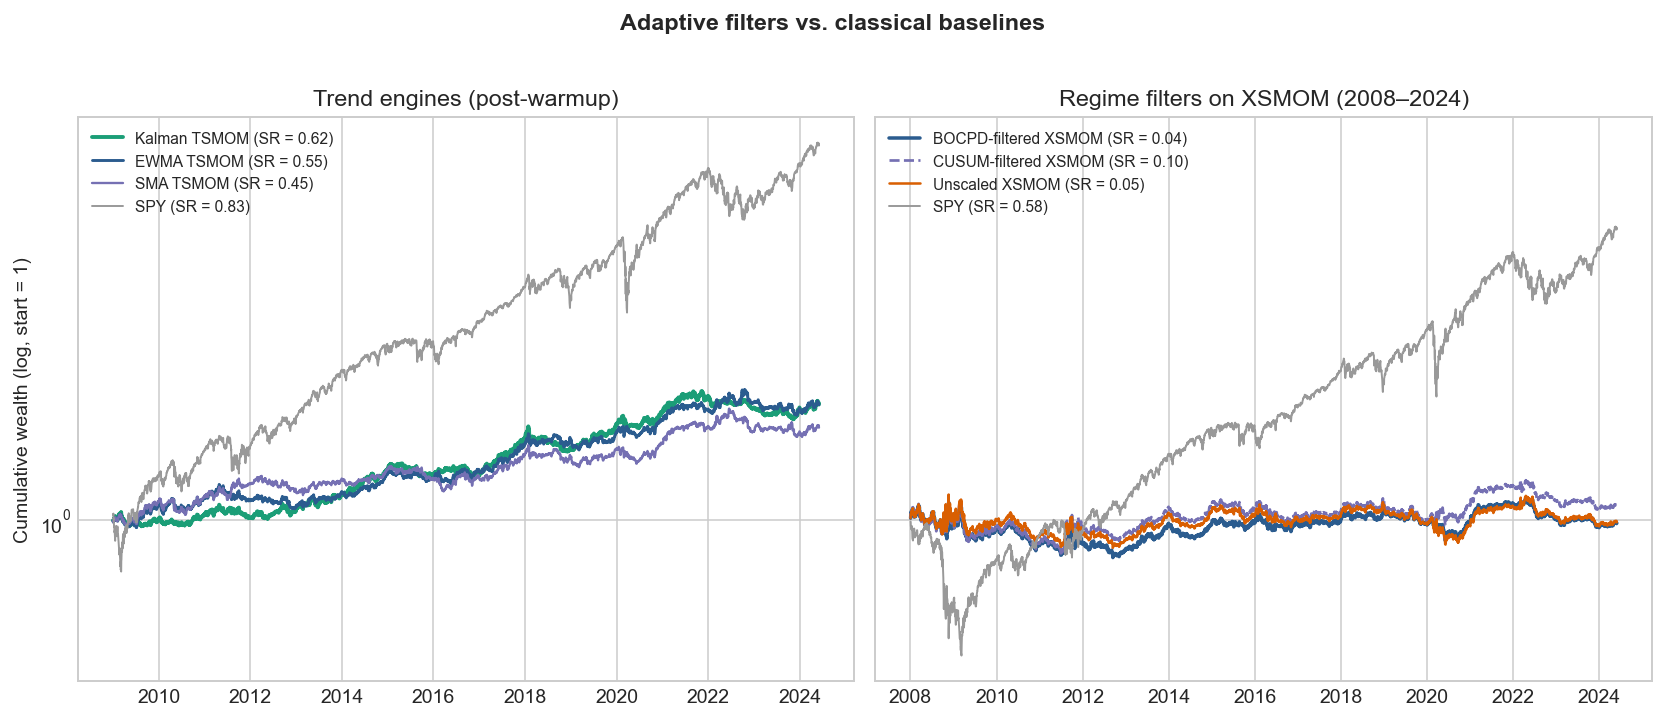

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=140, sharey=True)


def wealth(r):
    return (1 + r.dropna()).cumprod()


def sr(r):
    r = r.dropna()
    return np.sqrt(TRADING_DAYS) * r.mean() / r.std()


ax = axes[0]
for name, series, color, lw in (
    ("Kalman TSMOM", ret_kalman.loc[post], "#1b9e77", 2.0),
    ("EWMA TSMOM", ret_ewma.loc[post], "#2b5c8f", 1.5),
    ("SMA TSMOM", ret_sma.loc[post], "#7570b3", 1.2),
    ("SPY", df_returns["SPY"].loc[post], "#999999", 1.0),
):
    ax.plot(wealth(series), label=f"{name} (SR = {sr(series):.2f})", color=color, lw=lw)
ax.set_yscale("log")
ax.set_title("Trend engines (post-warmup)")
ax.set_ylabel("Cumulative wealth (log, start = 1)")
ax.legend(loc="upper left", fontsize=8)

ax = axes[1]
for name, series, color, lw, ls in (
    ("BOCPD-filtered XSMOM", filter_returns["BOCPD-filtered XSMOM"], "#2b5c8f", 1.8, "-"),
    ("CUSUM-filtered XSMOM", filter_returns["CUSUM-filtered XSMOM"], "#7570b3", 1.4, "--"),
    ("Unscaled XSMOM", filter_returns["Unscaled XSMOM"], "#d95f02", 1.3, "-"),
    ("SPY", filter_returns["S&P 500 (SPY)"], "#999999", 1.0, "-"),
):
    ax.plot(wealth(series), label=f"{name} (SR = {sr(series):.2f})", color=color, lw=lw, ls=ls)
ax.set_yscale("log")
ax.set_title("Regime filters on XSMOM (2008–2024)")
ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Adaptive filters vs. classical baselines", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## 6. Statistical significance

HAC $t$-statistics (Newey–West automatic bandwidth), Mertens Sharpe standard errors, stationary bootstrap intervals, and Benjamini–Hochberg within each table. The comparison that actually answers the notebook's questions is the Jobson–Korkie test of **Kalman vs. EWMA** and **BOCPD vs. unscaled XSMOM** — not vs. zero, and not vs. SPY. A detector can reject zero and still be indistinguishable from the thing it replaced.


In [10]:
def newey_west_tstat(returns: pd.Series):
    r = returns.to_numpy(dtype=float)
    T = len(r)
    lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    e = r - r.mean()
    var = e @ e / T
    for lag in range(1, lags + 1):
        var += 2 * (1 - lag / (lags + 1)) * (e[lag:] @ e[:-lag]) / T
    t_stat = r.mean() / np.sqrt(var / T)
    return t_stat, 2 * stats.norm.sf(abs(t_stat)), lags


def sharpe_standard_error(returns: pd.Series) -> float:
    r = returns.to_numpy(dtype=float)
    sr_d = r.mean() / r.std(ddof=1)
    skew, kurt = stats.skew(r), stats.kurtosis(r, fisher=False)
    var = (1 + 0.5 * sr_d ** 2 - skew * sr_d + (kurt - 3) / 4 * sr_d ** 2) / len(r)
    return np.sqrt(var * TRADING_DAYS)


def bootstrap_sharpe_ci(returns: pd.Series, n_boot=1000, mean_block=21, seed=0):
    rng = np.random.default_rng(seed)
    r = returns.to_numpy(dtype=float)
    T = len(r)
    idx = np.empty((n_boot, T), dtype=np.int64)
    idx[:, 0] = rng.integers(0, T, n_boot)
    restart = rng.random((n_boot, T)) < 1 / mean_block
    fresh = rng.integers(0, T, (n_boot, T))
    for t in range(1, T):
        idx[:, t] = np.where(restart[:, t], fresh[:, t], (idx[:, t - 1] + 1) % T)
    draws = r[idx]
    sr_b = np.sqrt(TRADING_DAYS) * draws.mean(axis=1) / draws.std(axis=1, ddof=1)
    return np.quantile(sr_b, 0.025), np.quantile(sr_b, 0.975)


def sharpe_difference_test(a: pd.Series, b: pd.Series):
    paired = pd.concat([a, b], axis=1, join="inner").dropna()
    x, y = paired.iloc[:, 0].to_numpy(), paired.iloc[:, 1].to_numpy()
    T = len(x)
    sr_a, sr_b = x.mean() / x.std(ddof=1), y.mean() / y.std(ddof=1)
    rho = np.corrcoef(x, y)[0, 1]
    theta = (2 * (1 - rho) + 0.5 * (sr_a ** 2 + sr_b ** 2 - 2 * rho ** 2 * sr_a * sr_b)) / T
    z = (sr_a - sr_b) / np.sqrt(theta)
    return z, 2 * stats.norm.sf(abs(z)), rho


def significance_table(strategies: dict) -> pd.DataFrame:
    rows = []
    nw_lags = None
    for name, r in strategies.items():
        sharpe = np.sqrt(TRADING_DAYS) * r.mean() / r.std()
        se = sharpe_standard_error(r)
        t_stat, p_value, nw_lags = newey_west_tstat(r)
        lo, hi = bootstrap_sharpe_ci(r)
        rows.append({
            "Sharpe": f"{sharpe:.2f}",
            "SE": f"{se:.2f}",
            "95% CI (boot)": f"[{lo:.2f}, {hi:.2f}]",
            "HAC t": f"{t_stat:.2f}",
            "p-value": p_value,
        })
    sig = pd.DataFrame(rows, index=list(strategies))
    sig["BH p"] = stats.false_discovery_control(sig["p-value"], method="bh")
    for col in ("p-value", "BH p"):
        sig[col] = sig[col].map(lambda v: f"{v:.3f}")
    years = len(next(iter(strategies.values()))) / TRADING_DAYS
    print(f"T = {len(next(iter(strategies.values())))} days ({years:.1f} y), L = {nw_lags}, Sharpe for t=2: {2 / np.sqrt(years):.2f}")
    return sig.T

print("Trend engines")
display(significance_table(trend_returns))
print("Regime filters")
display(significance_table(filter_returns))

pairs = [
    ("Kalman TSMOM vs EWMA TSMOM", trend_returns["Kalman TSMOM"], trend_returns["EWMA TSMOM"]),
    ("Kalman TSMOM vs SMA TSMOM", trend_returns["Kalman TSMOM"], trend_returns["SMA TSMOM"]),
    ("BOCPD vs unscaled XSMOM", filter_returns["BOCPD-filtered XSMOM"], filter_returns["Unscaled XSMOM"]),
    ("CUSUM vs unscaled XSMOM", filter_returns["CUSUM-filtered XSMOM"], filter_returns["Unscaled XSMOM"]),
    ("BOCPD vs CUSUM", filter_returns["BOCPD-filtered XSMOM"], filter_returns["CUSUM-filtered XSMOM"]),
]
diff_rows = {}
for label, a, b in pairs:
    z, p, rho = sharpe_difference_test(a, b)
    sa = np.sqrt(TRADING_DAYS) * a.mean() / a.std()
    sb = np.sqrt(TRADING_DAYS) * b.mean() / b.std()
    diff_rows[label] = {
        "SR A": f"{sa:.2f}", "SR B": f"{sb:.2f}", "Diff": f"{sa - sb:+.2f}",
        "Corr": f"{rho:.2f}", "JK z": f"{z:.2f}", "p": f"{p:.3f}",
    }
print("Jobson-Korkie tests (does the adaptive filter beat the thing it replaced?)")
display(pd.DataFrame(diff_rows))


Trend engines


T = 3878 days (15.4 y), L = 9, Sharpe for t=2: 0.51


,Kalman TSMOM,EWMA TSMOM,SMA TSMOM,S&P 500 (SPY)
Sharpe,0.62,0.55,0.45,0.83
SE,0.26,0.26,0.26,0.26
95% CI (boot),"[0.20, 1.08]","[0.16, 1.02]","[0.06, 0.91]","[0.36, 1.30]"
HAC t,2.60,2.37,1.89,3.63
p-value,0.009,0.018,0.058,0.000
BH p,0.019,0.024,0.058,0.001


Regime filters


T = 4132 days (16.4 y), L = 9, Sharpe for t=2: 0.49


,Unscaled XSMOM,CUSUM-filtered XSMOM,BOCPD-filtered XSMOM,S&P 500 (SPY)
Sharpe,0.05,0.10,0.04,0.58
SE,0.25,0.25,0.25,0.25
95% CI (boot),"[-0.32, 0.41]","[-0.30, 0.50]","[-0.35, 0.41]","[0.19, 1.11]"
HAC t,0.28,0.46,0.20,2.74
p-value,0.781,0.643,0.839,0.006
BH p,0.839,0.839,0.839,0.024


Jobson-Korkie tests (does the adaptive filter beat the thing it replaced?)


,Kalman TSMOM vs EWMA TSMOM,Kalman TSMOM vs SMA TSMOM,BOCPD vs unscaled XSMOM,CUSUM vs unscaled XSMOM,BOCPD vs CUSUM
SR A,0.62,0.62,0.04,0.10,0.04
SR B,0.55,0.45,0.05,0.05,0.10
Diff,+0.07,+0.17,-0.01,+0.05,-0.06
Corr,0.75,0.66,0.96,0.96,0.94
JK z,0.34,0.79,-0.17,0.67,-0.70
p,0.733,0.430,0.863,0.501,0.482


### What the tests actually say

Read the Jobson–Korkie table before the equity curves. Two results are worth separating, because they answer different questions.

**Kalman versus EWMA is a horse race between two trend engines.** SMA vs EWMA return correlation is $0.91$, which is the linear-filter theorem. Kalman vs EWMA is $0.75$ with a position correlation of only $0.50$: the time-varying gain *does* change the positions. The Sharpe gap is $+0.07$ ($0.62$ vs $0.55$) and the Jobson–Korkie $p$-value is $0.73$. Kalman prints the higher point estimate, both reject zero after FDR control, and they are indistinguishable from each other. That is a real adaptive filter that does not, on 15 years, earn a distinguishable premium over EWMA.

**BOCPD versus CUSUM versus raw XSMOM is a horse race between crash filters.** Both fire in 2008 (CUSUM 31 of its 70 hits; BOCPD 19 of 207 days with $\Pr(r<21)>0.5$), 2011 and 2020. CUSUM lifts Sharpe $0.05 \to 0.10$ ($t = 0.46$, JK $p = 0.50$ vs raw). BOCPD is more trigger-happy — it also cuts 2014–2016, 2018, 2019 and 2022 — and the Sharpe goes *sideways* to $0.04$ (JK $p = 0.86$ vs raw, $p = 0.48$ vs CUSUM). Firing in the right years is not the same as improving the Sharpe by more than its standard error. The conclusion is not that Bayesian run-length tracking is a bad idea; it is that a 10-name ETF book cannot resolve it. Factor momentum, with a century of monthly data, was the sample that could.

Two implementation choices that would manufacture a result: fitting the Kalman $Q, R$ on the full sample (hyperparameter look-ahead), and treating $\Pr(r_t = 0)$ as the BOCPD detection statistic (it equals $H$ identically). Neither is used above.
